In [1]:
# Imports and basic setup

import os
import re
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from tictactoe_game import TicTacToeGame
from model import PolicyValueNet
from mcts import MCTS

BASE_DIR = os.getcwd()
MODELS_DIR = os.path.join(BASE_DIR, "trained_models")

print("BASE_DIR:", BASE_DIR)
print("MODELS_DIR:", MODELS_DIR)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Fix random seeds for reproducibility (optional)
np.random.seed(42)
torch.manual_seed(42)

# Shared game instance for evaluation
game = TicTacToeGame()
print("Board size:", game.row_count, "x", game.column_count)
print("Action size:", game.action_size)


BASE_DIR: d:\Python\my_side_projects\TactiQ\alphazero_version
MODELS_DIR: d:\Python\my_side_projects\TactiQ\alphazero_version\trained_models
Device: cpu
Board size: 4 x 4
Action size: 16


In [2]:
# Helper functions: parsing iteration, loading model, random moves, single game vs random

def parse_iteration_from_filename(path: str) -> int | None:
    """
    Extract iteration index from 'model_X.pth' filename.
    Example: 'model_2.pth' -> 2
    """
    name = os.path.basename(path)
    m = re.search(r"model_(\d+)\.pth", name)
    return int(m.group(1)) if m else None


def load_model(checkpoint_path: str, game: TicTacToeGame, device: torch.device) -> PolicyValueNet:
    """
    Create a PolicyValueNet with the same architecture as in train.py
    and load weights from the given checkpoint.
    """
    # Must match train.py: PolicyValueNet(game, num_res_blocks=4, num_hidden=64, device=device)
    model = PolicyValueNet(
        game=game,
        num_res_blocks=4,
        num_hidden=64,
        device=device,
    )
    state_dict = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(state_dict)
    model.eval()
    return model


def select_random_action(state: np.ndarray) -> int:
    """
    Uniform random legal move for the current board state.
    State contains values in {-1, 0, +1}.
    """
    valid_moves = game.get_valid_moves(state)  # 1 for legal, 0 for illegal
    valid_indices = np.flatnonzero(valid_moves == 1)
    if len(valid_indices) == 0:
        return -1  # no legal moves
    return int(np.random.choice(valid_indices))


def play_single_game_vs_random(
    game: TicTacToeGame,
    model: PolicyValueNet,
    agent_player: int,
    num_searches: int = 100,
    C: float = 2.0,
) -> str:
    """
    Play one full game:
        - agent uses MCTS guided by the network,
        - opponent plays uniformly random legal moves.

    agent_player: +1 -> agent is X (starts), -1 -> agent is O.
    Returns: "agent", "random", or "draw".
    """
    mcts_args = {
        "C": C,
        "num_searches": num_searches,
    }
    mcts = MCTS(game, mcts_args, model)

    state = game.get_initial_state()
    current_player = 1  # X always starts

    while True:
        if current_player == agent_player:
            # Agent uses MCTS (greedy w.r.t. visit counts)
            neutral_state = game.change_perspective(state, current_player)
            action_probs = mcts.search(neutral_state)
            action = int(np.argmax(action_probs))
        else:
            # Opponent is random
            action = select_random_action(state)
            if action == -1:
                # No legal moves: treat as draw
                return "draw"

        # Apply chosen action on the real board
        state = game.get_next_state(state, action, current_player)

        # Evaluate outcome from board logic
        value, is_terminal = game.get_value_and_terminated(state, action)
        if is_terminal:
            if value == 1:
                # The player who just moved has won
                return "agent" if current_player == agent_player else "random"
            else:
                # value == 0 -> draw
                return "draw"

        # Switch player
        current_player = game.get_opponent(current_player)


In [3]:
# Evaluation of one model against random as X and as O

def evaluate_model_against_random(
    model: PolicyValueNet,
    game: TicTacToeGame,
    num_episodes: int = 300,
    num_searches: int = 100,
) -> list[dict]:
    """
    For a given model, run:
        - agent as X vs random O
        - agent as O vs random X

    Returns a list of dict rows suitable for building a DataFrame.
    """
    results = []

    for agent_player, scenario_label in [(1, "Modell X-ként"), (-1, "Modell O-ként")]:
        agent_wins = 0
        random_wins = 0
        draws = 0

        for _ in range(num_episodes):
            outcome = play_single_game_vs_random(
                game=game,
                model=model,
                agent_player=agent_player,
                num_searches=num_searches,
            )
            if outcome == "agent":
                agent_wins += 1
            elif outcome == "random":
                random_wins += 1
            else:
                draws += 1

        episodes = num_episodes
        agent_win_rate = agent_wins / episodes
        draw_rate = draws / episodes
        loss_rate = random_wins / episodes

        results.append(
            {
                "scenario": scenario_label,
                "episodes": episodes,
                "agent_wins": agent_wins,
                "random_wins": random_wins,
                "draws": draws,
                "agent_win_rate": agent_win_rate,
                "draw_rate": draw_rate,
                "loss_rate": loss_rate,
            }
        )

    return results


In [4]:
# Discover all saved model checkpoints in trained_models/

checkpoint_paths = []
if os.path.isdir(MODELS_DIR):
    for name in os.listdir(MODELS_DIR):
        if name.startswith("model_") and name.endswith(".pth"):
            checkpoint_paths.append(os.path.join(MODELS_DIR, name))

if not checkpoint_paths:
    raise RuntimeError(f"No model_*.pth checkpoints found in {MODELS_DIR}")

# Sort by iteration index (model_0.pth, model_1.pth, ...)
checkpoint_paths = sorted(
    checkpoint_paths,
    key=lambda p: parse_iteration_from_filename(p) or 0,
)

checkpoint_paths


['d:\\Python\\my_side_projects\\TactiQ\\alphazero_version\\trained_models\\model_0.pth',
 'd:\\Python\\my_side_projects\\TactiQ\\alphazero_version\\trained_models\\model_1.pth',
 'd:\\Python\\my_side_projects\\TactiQ\\alphazero_version\\trained_models\\model_2.pth']

In [5]:
# Run evaluation vs random for all checkpoints and collect into a DataFrame,
# then rename columns to Hungarian.

rows = []

for ckpt_path in checkpoint_paths:
    iteration = parse_iteration_from_filename(ckpt_path)
    model_name = os.path.basename(ckpt_path)
    print(f"Evaluating vs random: {model_name} (iteration {iteration})...")

    model = load_model(ckpt_path, game, device)

    eval_rows = evaluate_model_against_random(
        model=model,
        game=game,
        num_episodes=300,
        num_searches=100,
    )

    for r in eval_rows:
        r["model_name"] = model_name
        r["iteration"] = iteration
        rows.append(r)

df = pd.DataFrame(rows)
df = df.sort_values(["iteration", "scenario"]).reset_index(drop=True)

df_hu = df.rename(
    columns={
        "model_name": "Modell",
        "iteration": "Iteráció",
        "scenario": "Szenárió",
        "episodes": "Epizódok száma",
        "agent_wins": "Modell győzelmek",
        "random_wins": "Random győzelmek",
        "draws": "Döntetlenek",
        "agent_win_rate": "Modell győzelmi arány",
        "draw_rate": "Döntetlen arány",
        "loss_rate": "Modell vereségi arány",
    }
)

df_hu


Evaluating vs random: model_0.pth (iteration 0)...
Evaluating vs random: model_1.pth (iteration 1)...
Evaluating vs random: model_2.pth (iteration 2)...


,Szenárió,Epizódok száma,Modell győzelmek,Random győzelmek,Döntetlenek,Modell győzelmi arány,Döntetlen arány,Modell vereségi arány,Modell,Iteráció
0,Modell O-ként,300,292,8,0,0.973333,0.0,0.026667,model_0.pth,0
1,Modell X-ként,300,300,0,0,1.000000,0.0,0.000000,model_0.pth,0
2,Modell O-ként,300,294,6,0,0.980000,0.0,0.020000,model_1.pth,1
3,Modell X-ként,300,300,0,0,1.000000,0.0,0.000000,model_1.pth,1
4,Modell O-ként,300,294,6,0,0.980000,0.0,0.020000,model_2.pth,2
5,Modell X-ként,300,300,0,0,1.000000,0.0,0.000000,model_2.pth,2


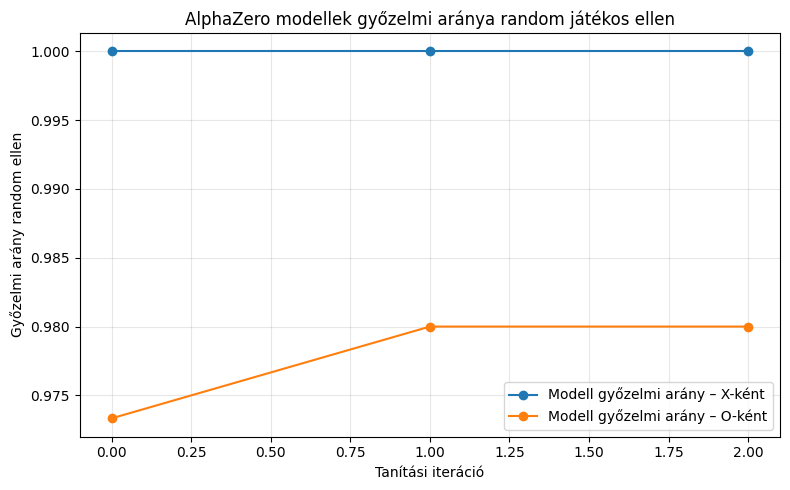

In [6]:
# Winrate vs iteration plot (model as X and as O vs random)

plt.figure(figsize=(8, 5))

for scenario_label, plot_label in [
    ("Modell X-ként", "Modell győzelmi arány – X-ként"),
    ("Modell O-ként", "Modell győzelmi arány – O-ként"),
]:
    mask = df["scenario"] == scenario_label
    sub = df[mask].sort_values("iteration")
    if sub.empty:
        continue
    plt.plot(
        sub["iteration"],
        sub["agent_win_rate"],
        marker="o",
        linestyle="-",
        label=plot_label,
    )

plt.xlabel("Tanítási iteráció")
plt.ylabel("Győzelmi arány random ellen")
plt.title("AlphaZero modellek győzelmi aránya random játékos ellen")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


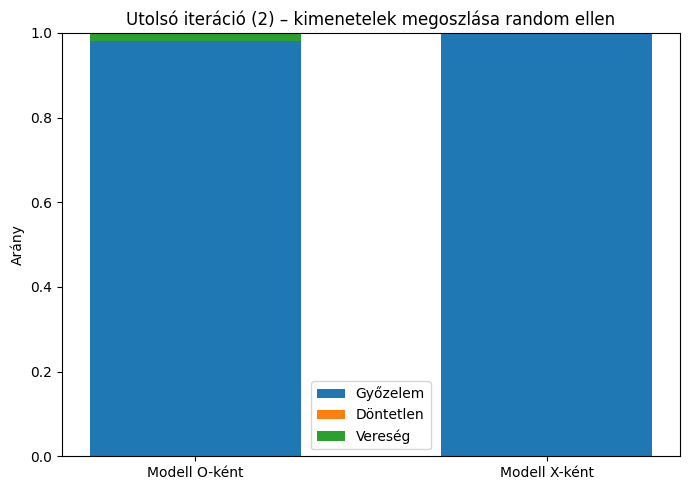

In [7]:
# Stacked bar plot for the last iteration vs random (win/draw/loss rates)

last_iter = df["iteration"].max()
mask_last = df["iteration"] == last_iter
sub_last = df[mask_last].copy()

if sub_last.empty:
    print("No data for last iteration.")
else:
    x = np.arange(len(sub_last))
    width = 0.6

    win = sub_last["agent_win_rate"].values
    draw = sub_last["draw_rate"].values
    loss = sub_last["loss_rate"].values

    labels = sub_last["scenario"].values

    plt.figure(figsize=(7, 5))
    plt.bar(x, win, width, label="Győzelem")
    plt.bar(x, draw, width, bottom=win, label="Döntetlen")
    plt.bar(x, loss, width, bottom=win + draw, label="Vereség")

    plt.xticks(x, labels, rotation=0)
    plt.ylabel("Arány")
    plt.title(f"Utolsó iteráció ({last_iter}) – kimenetelek megoszlása random ellen")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [8]:
# Self-play helpers: AlphaZero model vs itself with MCTS

def play_self_play_game_mcts(
    model: PolicyValueNet,
    game: TicTacToeGame,
    num_searches: int = 100,
    C: float = 2.0,
) -> int:
    """
    Play one full self-play game where BOTH players use the same
    AlphaZero-style model + MCTS.

    Returns:
        +1 -> starting player (X) wins
        -1 -> second player (O) wins
         0 -> draw
    """
    eval_args = {
        "C": C,
        "num_searches": num_searches,
    }
    mcts = MCTS(game, eval_args, model)

    state = game.get_initial_state()
    player = 1  # X starts

    while True:
        neutral_state = game.change_perspective(state, player)
        action_probs = mcts.search(neutral_state)
        action = int(np.argmax(action_probs))

        state = game.get_next_state(state, action, player)

        value, is_terminal = game.get_value_and_terminated(state, action)

        if is_terminal:
            if value == 1:
                return player
            else:
                return 0

        player = game.get_opponent(player)


def evaluate_model_self_play(
    model: PolicyValueNet,
    game: TicTacToeGame,
    num_episodes: int = 300,
    num_searches: int = 100,
) -> dict:
    """
    Evaluate one checkpoint by letting it play against itself with MCTS.

    Returns a summary dict with:
        - scenario
        - episodes
        - wins_as_x
        - wins_as_o
        - draws
        - win_rate_x
        - win_rate_o
        - draw_rate
    """
    wins_as_x = 0
    wins_as_o = 0
    draws = 0

    for _ in range(num_episodes):
        winner = play_self_play_game_mcts(
            model=model,
            game=game,
            num_searches=num_searches,
        )

        if winner == 1:
            wins_as_x += 1
        elif winner == -1:
            wins_as_o += 1
        else:
            draws += 1

    total = num_episodes
    win_rate_x = wins_as_x / total
    win_rate_o = wins_as_o / total
    draw_rate = draws / total

    return {
        "scenario": "Self-play (MCTS vs MCTS)",
        "episodes": total,
        "wins_as_x": wins_as_x,
        "wins_as_o": wins_as_o,
        "draws": draws,
        "win_rate_x": win_rate_x,
        "win_rate_o": win_rate_o,
        "draw_rate": draw_rate,
    }


In [9]:
# Evaluate all checkpoints in self-play (model vs itself with MCTS)

self_rows = []

for ckpt_path in checkpoint_paths:
    iteration = parse_iteration_from_filename(ckpt_path)
    model_name = os.path.basename(ckpt_path)
    print(f"Self-play evaluating {model_name} (iteration {iteration})...")

    model = load_model(ckpt_path, game, device)

    row = evaluate_model_self_play(
        model=model,
        game=game,
        num_episodes=300,   # can be increased later
        num_searches=100,   # MCTS strength during evaluation
    )
    row["model_name"] = model_name
    row["iteration"] = iteration
    self_rows.append(row)

df_self = pd.DataFrame(self_rows)
df_self = df_self.sort_values("iteration").reset_index(drop=True)

df_self_hu = df_self.rename(
    columns={
        "model_name": "Modell",
        "iteration": "Iteráció",
        "scenario": "Szenárió",
        "episodes": "Epizódok száma",
        "wins_as_x": "Győzelmek X-ként",
        "wins_as_o": "Győzelmek O-ként",
        "draws": "Döntetlenek",
        "win_rate_x": "Győzelmi arány X-ként",
        "win_rate_o": "Győzelmi arány O-ként",
        "draw_rate": "Döntetlen arány",
    }
)

df_self_hu


Self-play evaluating model_0.pth (iteration 0)...
Self-play evaluating model_1.pth (iteration 1)...
Self-play evaluating model_2.pth (iteration 2)...


,Szenárió,Epizódok száma,Győzelmek X-ként,Győzelmek O-ként,Döntetlenek,Győzelmi arány X-ként,Győzelmi arány O-ként,Döntetlen arány,Modell,Iteráció
0,Self-play (MCTS vs MCTS),300,300,0,0,1.0,0.0,0.0,model_0.pth,0
1,Self-play (MCTS vs MCTS),300,300,0,0,1.0,0.0,0.0,model_1.pth,1
2,Self-play (MCTS vs MCTS),300,300,0,0,1.0,0.0,0.0,model_2.pth,2


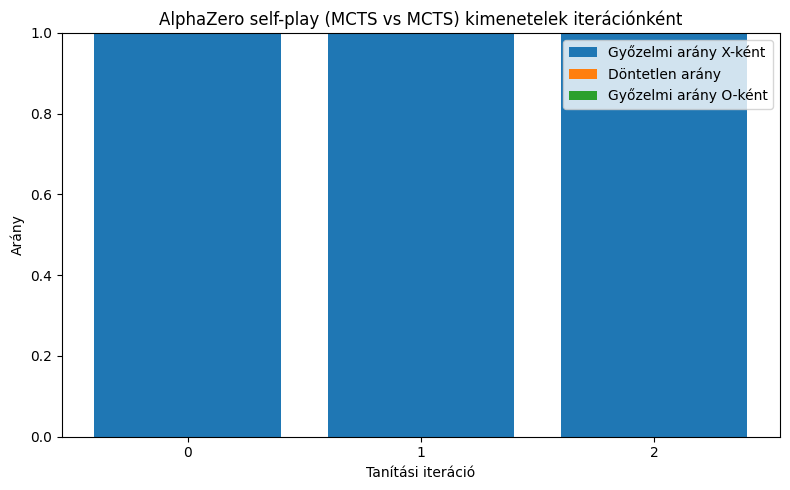

In [10]:
# Self-play visualization per iteration (stacked bar of X wins / draws / O wins)

if df_self.empty:
    print("No self-play data available.")
else:
    plt.figure(figsize=(8, 5))

    iters = df_self["iteration"].values
    x = np.arange(len(iters))

    w_x = df_self["win_rate_x"].values
    w_o = df_self["win_rate_o"].values
    d = df_self["draw_rate"].values

    plt.bar(x, w_x, label="Győzelmi arány X-ként")
    plt.bar(x, d, bottom=w_x, label="Döntetlen arány")
    plt.bar(x, w_o, bottom=w_x + d, label="Győzelmi arány O-ként")

    plt.xticks(x, iters)
    plt.xlabel("Tanítási iteráció")
    plt.ylabel("Arány")
    plt.title("AlphaZero self-play (MCTS vs MCTS) kimenetelek iterációnként")
    plt.legend()
    plt.tight_layout()
    plt.show()
